#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import ternary

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
import matplotlib.font_manager
from matplotlib.font_manager import fontManager
path = f"{indir}/arial.ttf"
fontManager.addfont(path)
matplotlib.rcParams['font.family'] = 'Arial'

In [ ]:
gene_df=pd.read_csv("../../../04.data/05.intermediate_files/01.RNA/01.Young_Mouse/all_gene_upset_group_list_new.csv")

In [4]:
gene_df_group=gene_df.groupby("group")

In [5]:
for i in gene_df_group:
    print(i[0])

[(5mCG+5hmCG) -]
[(5mCH+5hmCH) +]
[(5mCH+5hmCH) -]
[5hmCG +]
[5hmCG +]:[(5mCG+5hmCG) +]
[5hmCG -]
[5hmCG -]:[(5mCG+5hmCG) -]
[5hmCH +]
[5hmCH +]:[(5mCH+5hmCH) +]
[5hmCH +]:[(5mCH+5hmCH) -]
CG +]
CG +]:[(5mCG+5hmCG) +]
CG +]:[5hmCG -]
CG +]:[5hmCG -]:[(5mCG+5hmCG) +]
CG +]:[5hmCG -]:[(5mCG+5hmCG) -]
CG -]
CG -]:[(5mCG+5hmCG) -]
CG -]:[5hmCG +]
CG -]:[5hmCG +]:[(5mCG+5hmCG) +]
CG -]:[5hmCG +]:[(5mCG+5hmCG) -]
CG -]:[5hmCG -]:[(5mCG+5hmCG) -]
CH +]
CH +]:[(5mCH+5hmCH) +]
CH +]:[5hmCH +]
CH +]:[5hmCH +]:[(5mCH+5hmCH) +]
CH +]:[5hmCH -]:[(5mCH+5hmCH) +]
CH -]
CH -]:[(5mCH+5hmCH) +]
CH -]:[(5mCH+5hmCH) -]
CH -]:[5hmCH +]
CH -]:[5hmCH +]:[(5mCH+5hmCH) +]
CH -]:[5hmCH +]:[(5mCH+5hmCH) -]
CH -]:[5hmCH -]:[(5mCH+5hmCH) -]


In [6]:
genes_df_green=gene_df_group.get_group("[5mCG -]:[5hmCG +]:[(5mCG+5hmCG) -]")

In [7]:
genes_df_yellow=gene_df_group.get_group("[5mCG -]:[5hmCG +]")

In [8]:
genes_df_green.loc[genes_df_green.index,"sum_of_correlation"]=\
    genes_df_green[["Correlation_5mC","Correlation_5hmC","Correlation_mC_hmC"]].abs().sum(axis=1)

/tmp/ipykernel_57280/1733397940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes_df_green.loc[genes_df_green.index,"sum_of_correlation"]=\


In [9]:
genes_df_yellow.loc[genes_df_yellow.index,"sum_of_correlation"]=\
    genes_df_yellow[["Correlation_5mC","Correlation_5hmC"]].abs().sum(axis=1)

/tmp/ipykernel_57280/543345245.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes_df_yellow.loc[genes_df_yellow.index,"sum_of_correlation"]=\


In [10]:
genes_df_green_sorted=genes_df_green.sort_values(by="sum_of_correlation", ascending=False)

In [11]:
genes_df_yellow_sorted=genes_df_yellow.sort_values(by="sum_of_correlation", ascending=False)

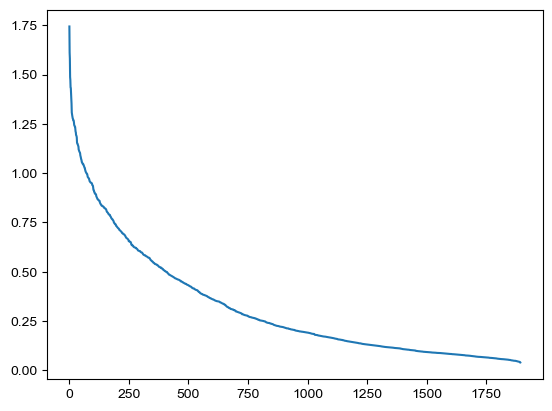

In [12]:
plt.plot(range(len(genes_df_green_sorted)), genes_df_green_sorted["sum_of_correlation"])

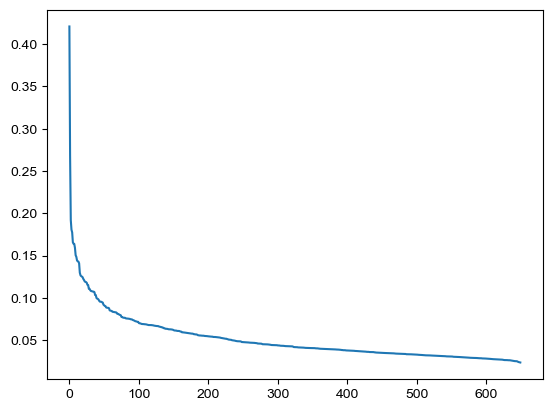

In [13]:
plt.plot(range(len(genes_df_yellow_sorted)), genes_df_yellow_sorted["sum_of_correlation"])

In [14]:
np.sum(genes_df_yellow_sorted["sum_of_correlation"]>0.1)

39

In [15]:
#都取前30个吧

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
meta_data=pd.read_csv("../../../04.data/02.metainfo/03.total/01.Young_Mouse/RNA_DNA_match_name_QC_class_label.csv",header=0)
meta_data2=meta_data[meta_data["total_QC"]==1]

In [ ]:
df_total5mC=ad.read_h5ad(f"{indir}/5mC_genebody.CG.pass_paired_QC.h5ad").to_df()

In [ ]:
df_5hmC=ad.read_h5ad(f"{indir}/5hmC_genebody.CG.pass_paired_QC.h5ad").to_df()

In [ ]:
df_RNA=ad.read_h5ad(f"{indir}/our_RNA_annotated_latest.h5ad").to_df()

In [20]:
df_RNA.index=[i.split("@@_")[1] for i in df_RNA.index]

In [ ]:
genes_df = pd.read_csv('../../../04.data/01.ref/Genebody.mm10.bed', sep='\t', header=None, names=['chromosome', 'start', 'end', 'gene_id', 'gene_name', 'strand'])

  0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_57280/3630494807.py:21: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax,cbar_ax) = plt.subplots(1,2,


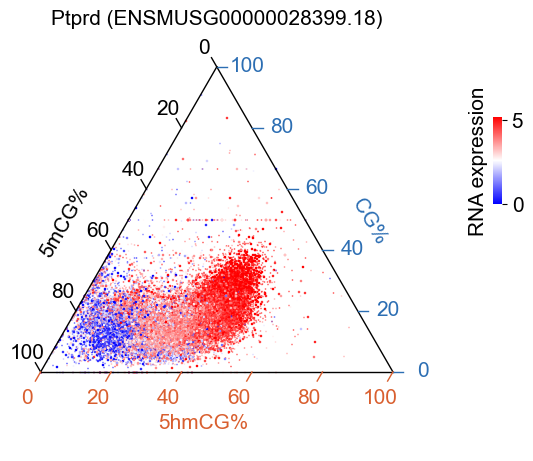

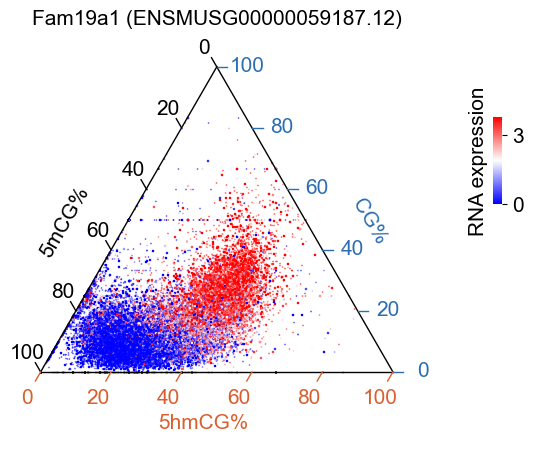

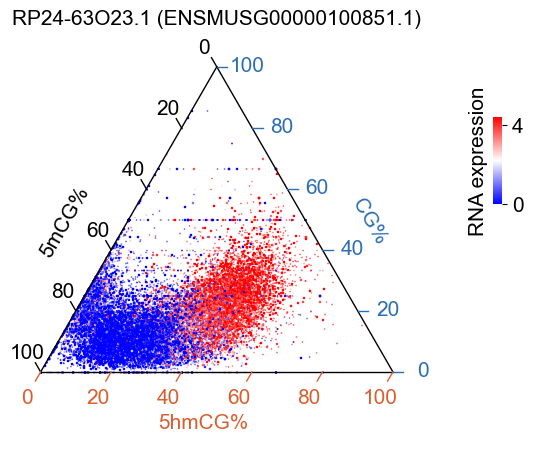

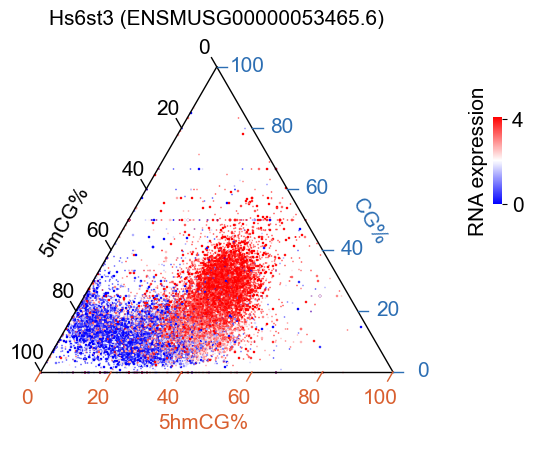

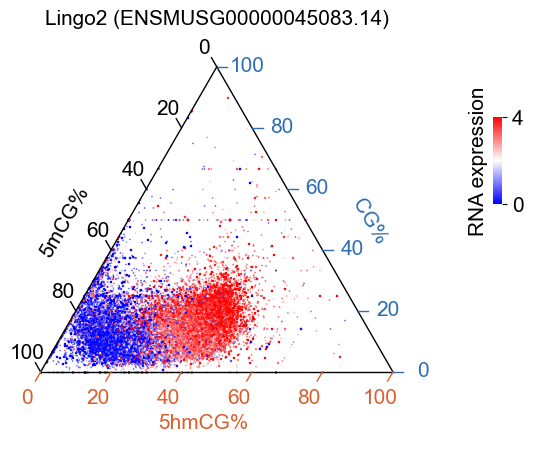

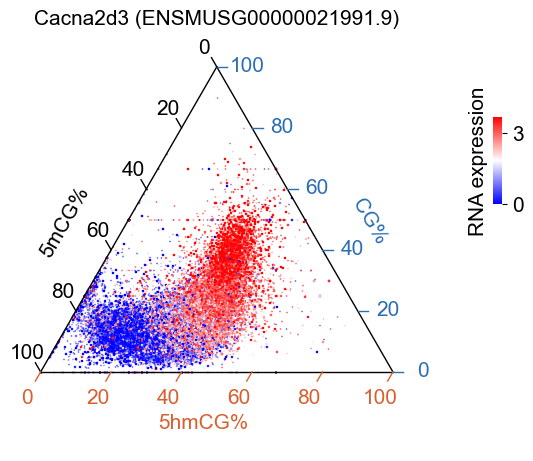

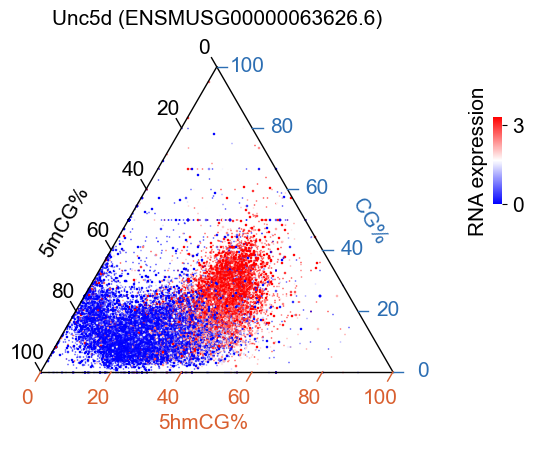

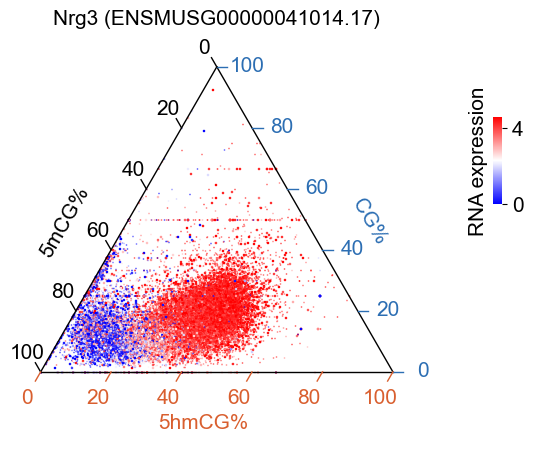

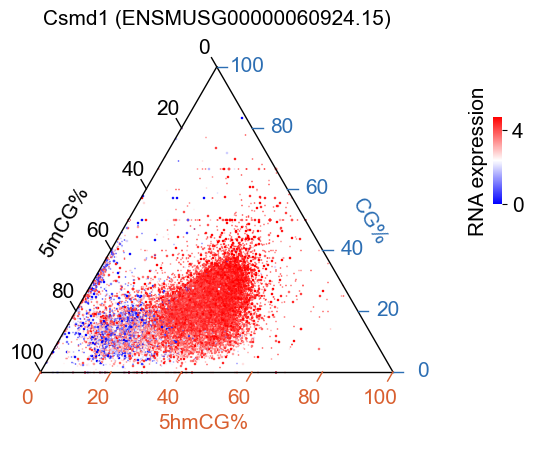

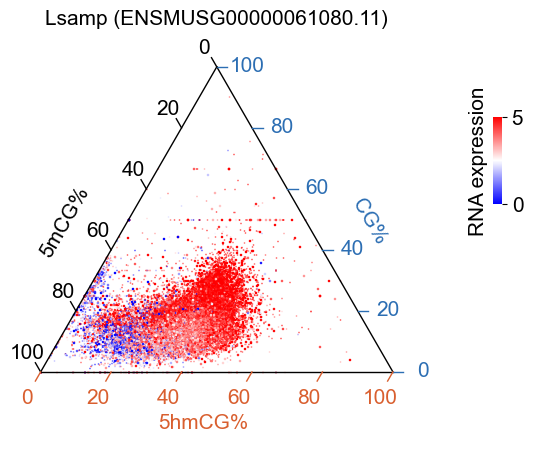

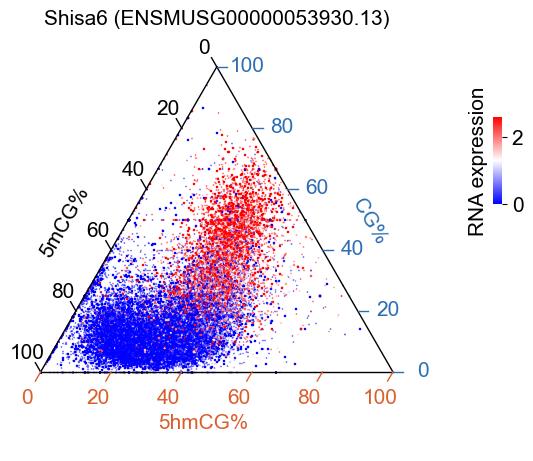

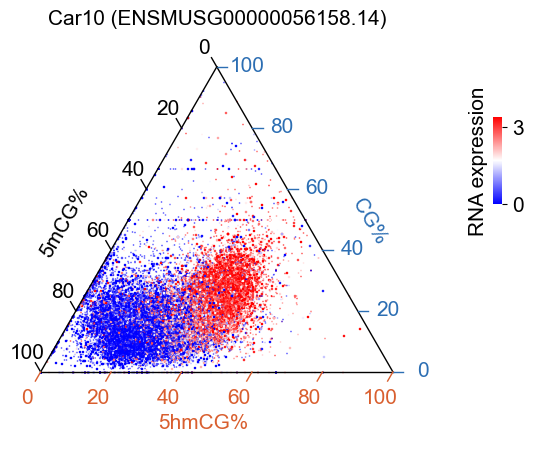

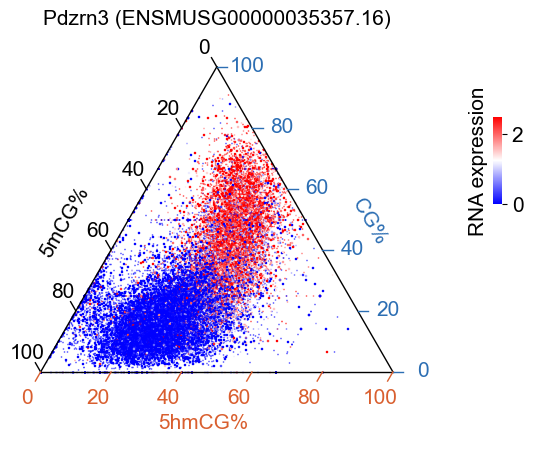

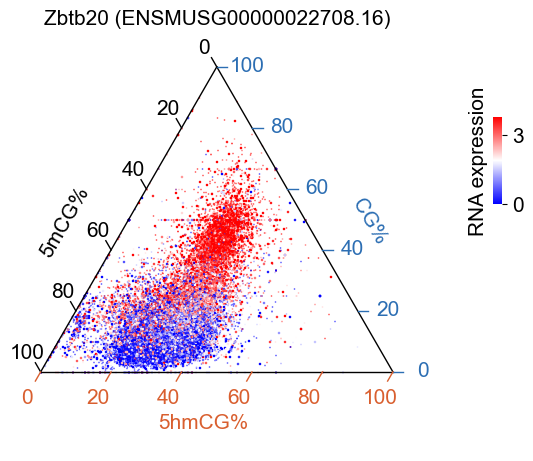

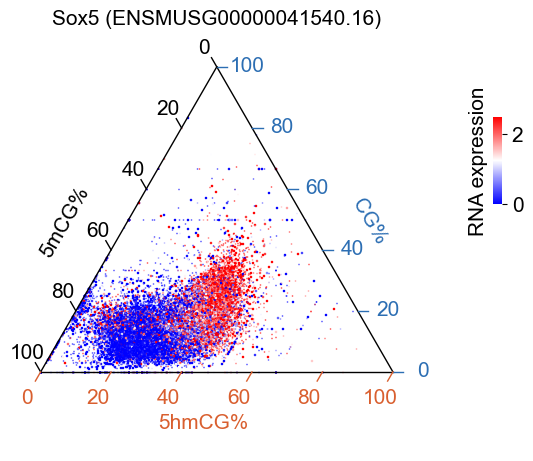

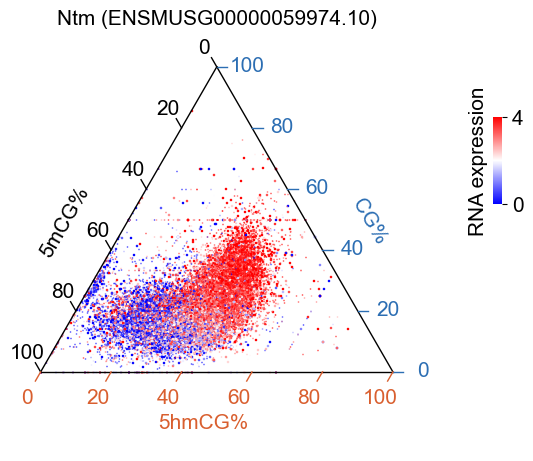

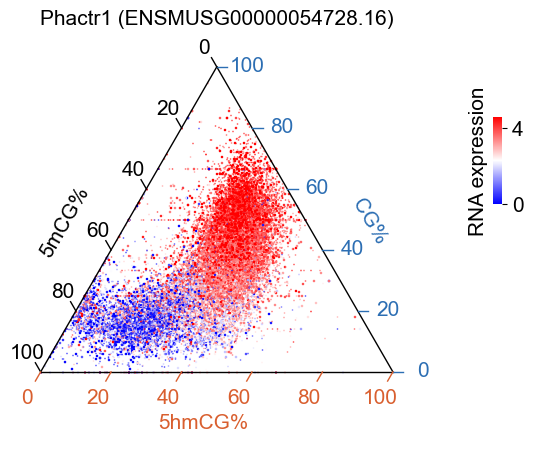

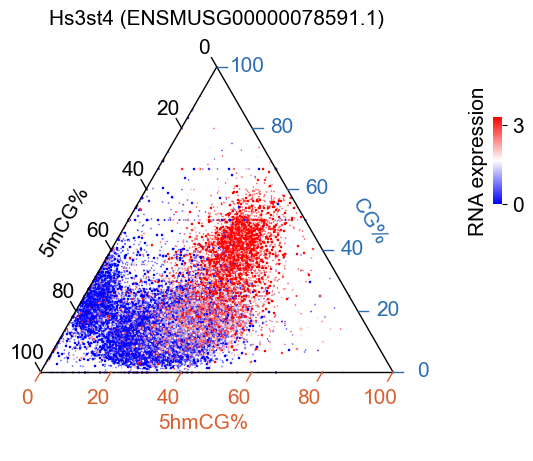

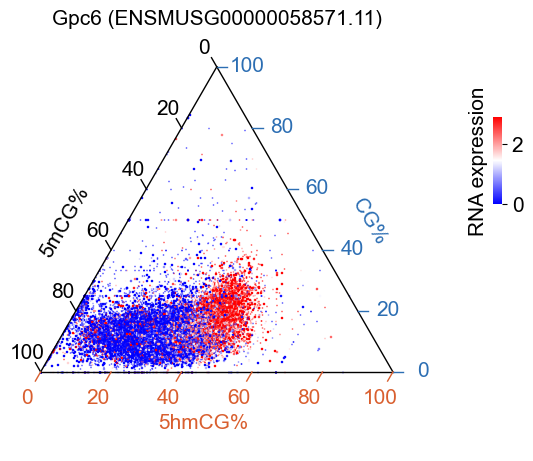

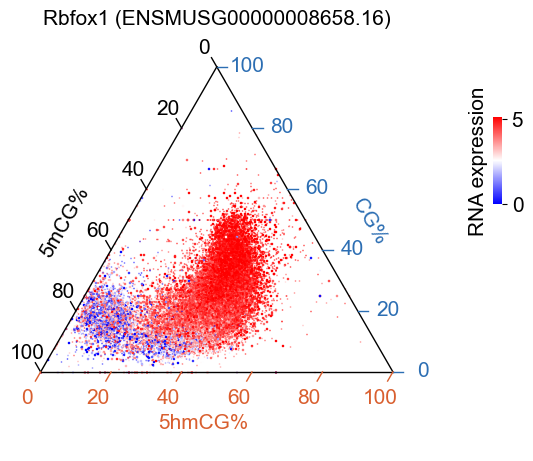

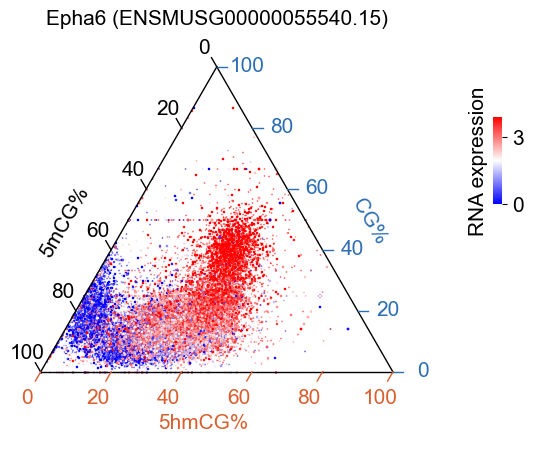

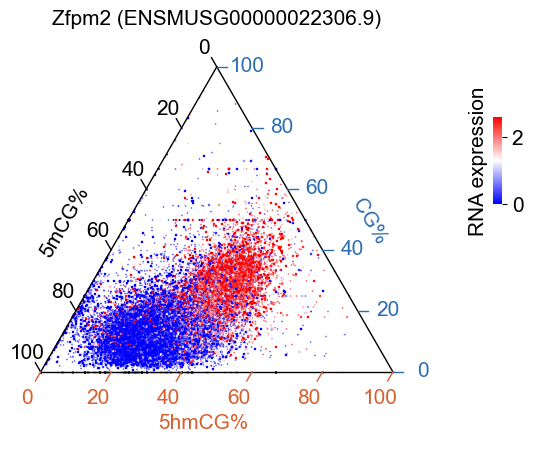

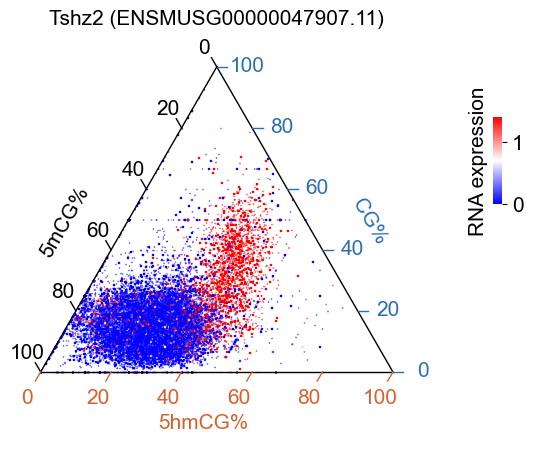

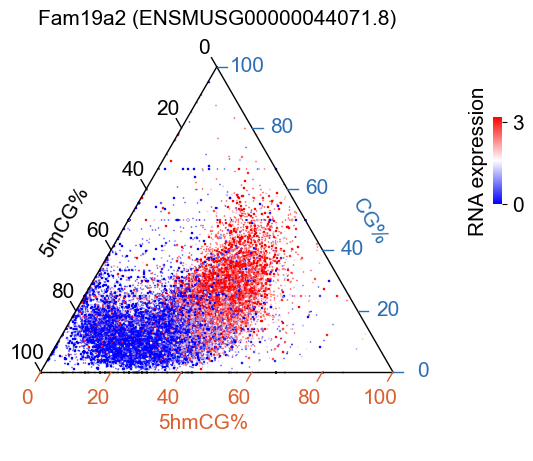

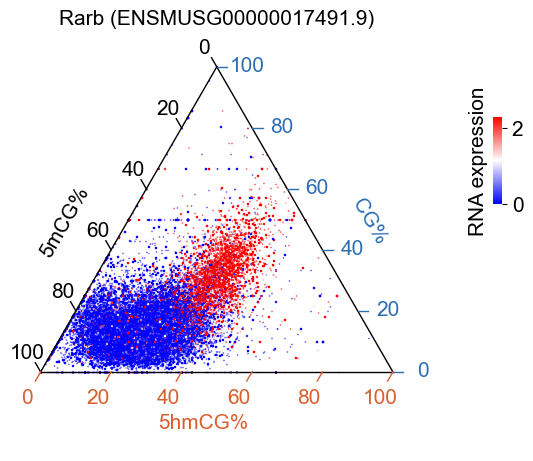

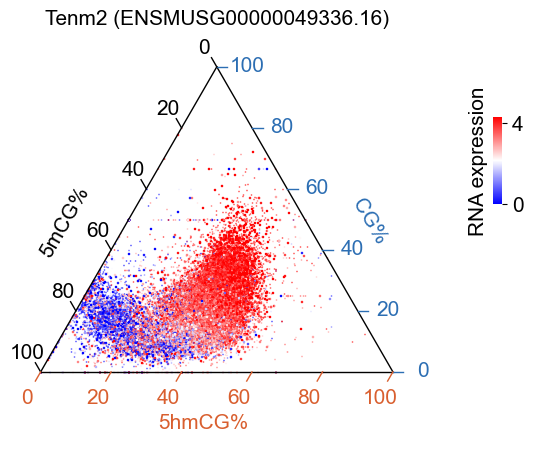

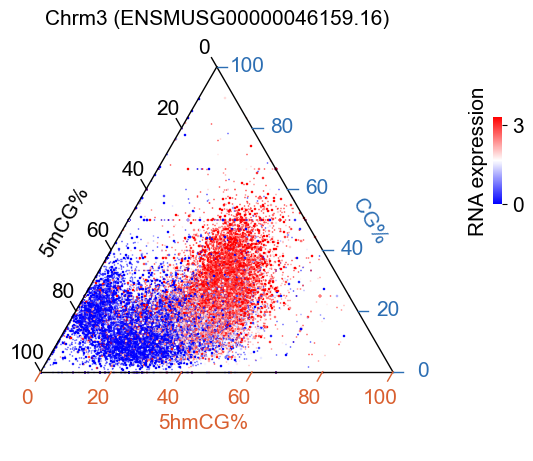

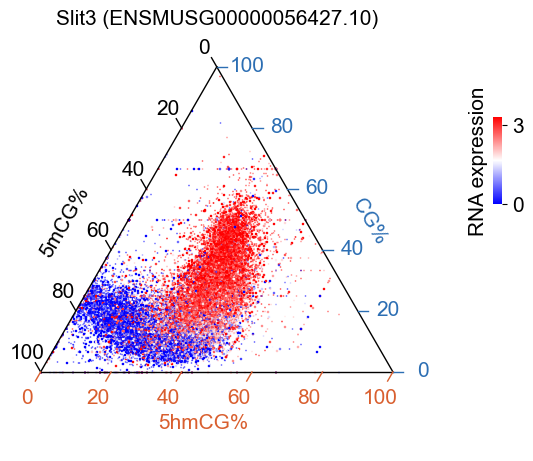

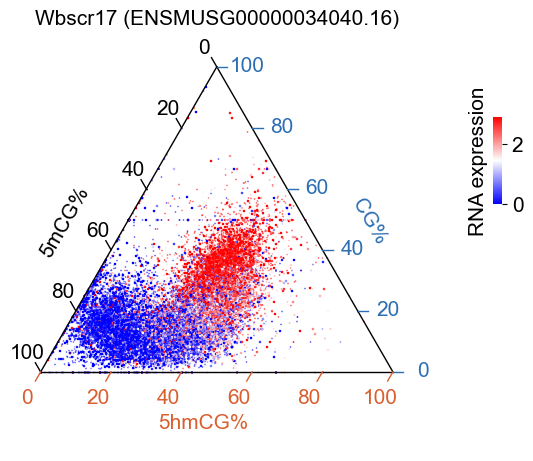

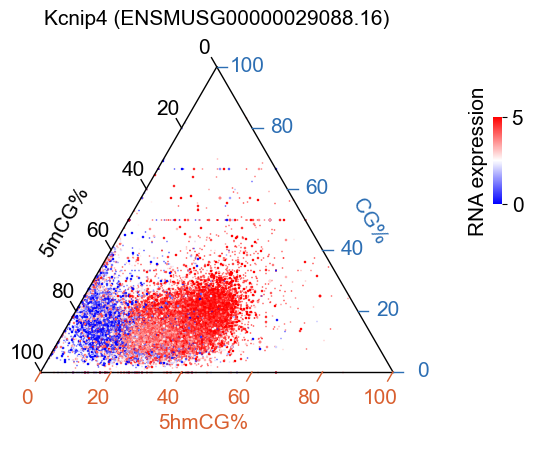

In [ ]:
for gene_ in tqdm(genes_df_green_sorted.iloc[:30,0]):
    gene_name=genes_df[genes_df["gene_id"]==gene_]["gene_name"].iloc[0]

    data_RNA=df_RNA.loc[meta_data2["RNA"], gene_]
    data_RNA.index=meta_data2["Unique_ID_match"]

    data_total5mC=df_total5mC.loc["allc_"+meta_data2["mC"], gene_]
    data_total5mC.index=meta_data2["Unique_ID_match"]

    data_5hmC=df_5hmC.loc["allc_"+meta_data2["hmC"], gene_]
    data_5hmC.index=meta_data2["Unique_ID_match"]

    data_5mC=data_total5mC-data_5hmC
    # note that data_5mC may contain negative values


    plt.rcParams["figure.autolayout"] = True
    temp_scale=3
    
    ## Boundary and Gridlines
    fig, (ax,cbar_ax) = plt.subplots(1,2,
                                     figsize=(temp_scale*46/25.4, temp_scale*40/25.4),
                                    width_ratios=[40,6])
    ax.set_aspect('equal')
    
    scale = 100
    figure, tax = ternary.figure(scale=scale,ax=ax)
    #figure.set_size_inches(temp_scale*60/25.4, temp_scale*60/25.4)
    tax.set_background_color("white")
    # Draw Boundary and Gridlines
    tax.boundary(linewidth=1)
    #tax.gridlines(color="black", multiple=6)
    #tax.gridlines(color="blue", multiple=2, linewidth=0.5)

    data_of_points=pd.concat([data_5hmC, 1-data_total5mC, data_5mC, data_RNA],axis=1)
    # bottom, right, left is the default order
    # remove negative true 5mC points
    data_of_points=data_of_points[data_5mC>=0]
    
    points = data_of_points.iloc[:,:3].to_numpy()*100
    
    color_data = data_of_points.iloc[:,3]
    vmax_RNA=np.floor(np.quantile(data_RNA, 0.9)*10)/10
    
    # Scatter plot with colors
    tax.scatter(points, marker=',', c=color_data, cmap='bwr', s=0.1,
                vmin=0, vmax=vmax_RNA)

    # Set Axis labels and Title
    fontsize = temp_scale*5
    tax.set_title(f"{gene_name} ({gene_})\n", fontsize=fontsize)
    tax.left_axis_label("5mCG%", fontsize=fontsize, offset=0.18,color="black")
    tax.right_axis_label("CG%", fontsize=fontsize, offset=0.18,color="#2C6EB3")
    tax.bottom_axis_label("5hmCG%", fontsize=fontsize, offset=0.14,color="#D95F2F")
    
    # Set ticks
    tax.ticks(axis='lbr', linewidth=1, multiple=20, offset=0.03, fontsize=fontsize,
             clockwise=False, axes_colors={"l":"black", "b":"#D95F2F", "r":"#2C6EB3"})
    
    # set colorbar
    sm = plt.cm.ScalarMappable(cmap='bwr',
                norm=plt.Normalize(vmin=0, vmax=vmax_RNA))
    sm.set_array([])
    # Create an axis for the color bar to prevent overlap
    cbar=plt.colorbar(sm, ax=cbar_ax, shrink=1,aspect=10,
                 location="right", anchor=(0,0.7),ticks=[0,int(vmax_RNA)], format='%d')
    cbar.ax.tick_params(labelsize=fontsize)
    #cbar.ax.set_yticks((0, vmax_RNA))
    cbar.ax.set_ylabel("RNA expression", fontsize=fontsize)
    cbar.ax.yaxis.set_label_position('left')
    cbar_ax.axis("off")
    # Disable edges of the colorbar
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)
    
    # Remove default Matplotlib Axes
    tax.clear_matplotlib_ticks()
    tax.get_axes().axis('off')

    #break
    
    ternary.plt.savefig(f"{outdir}/plot_[5mCG -]_[5hmCG +]_[(5mCG+5hmCG) -]/{gene_name}.pdf")
    #ternary.plt.show()
    #break

  0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_57280/3279878895.py:21: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax,cbar_ax) = plt.subplots(1,2,


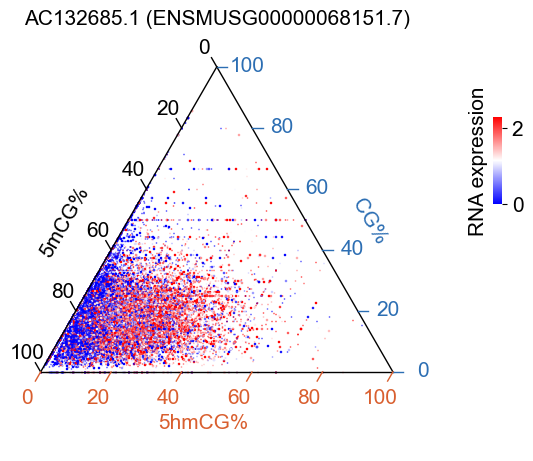

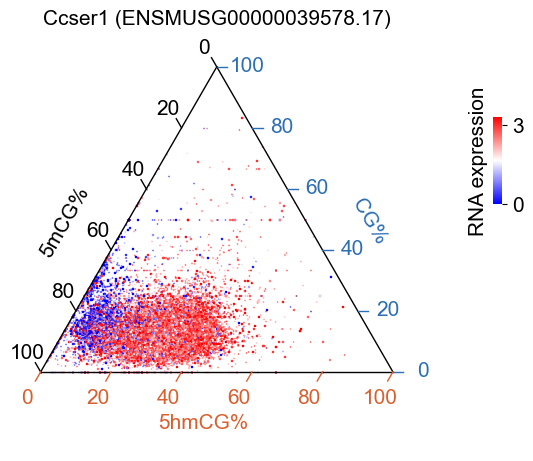

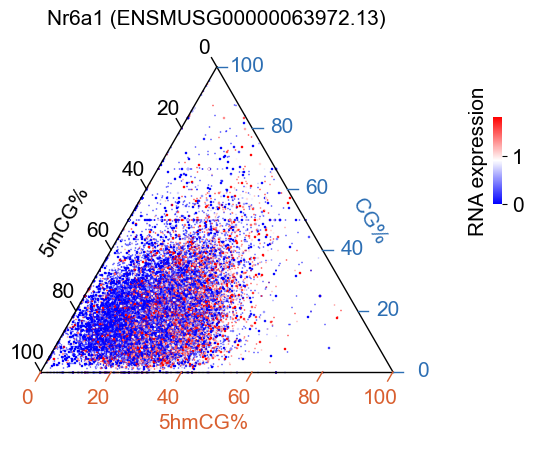

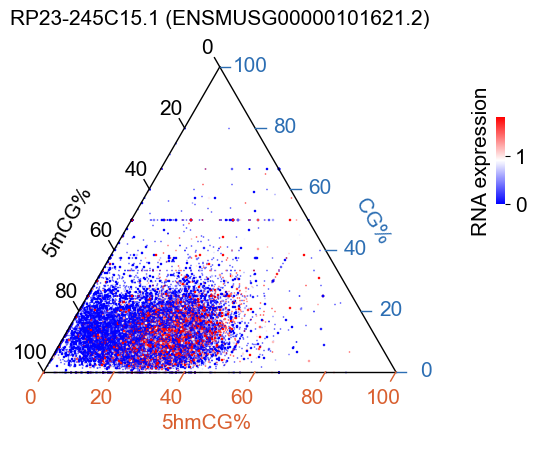

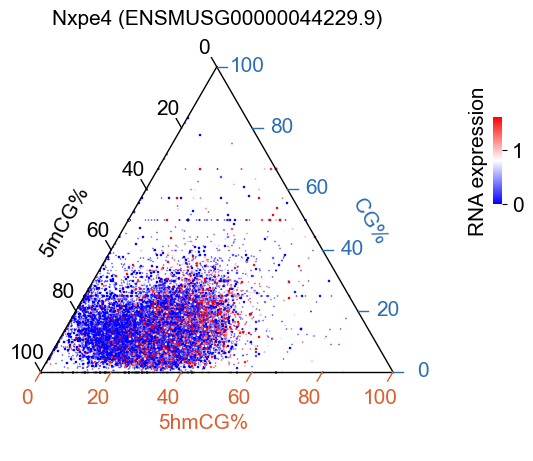

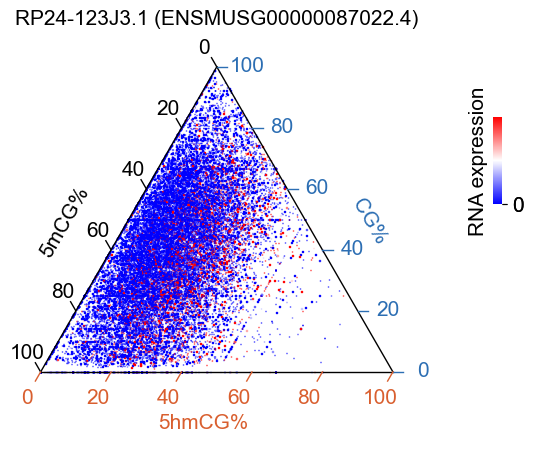

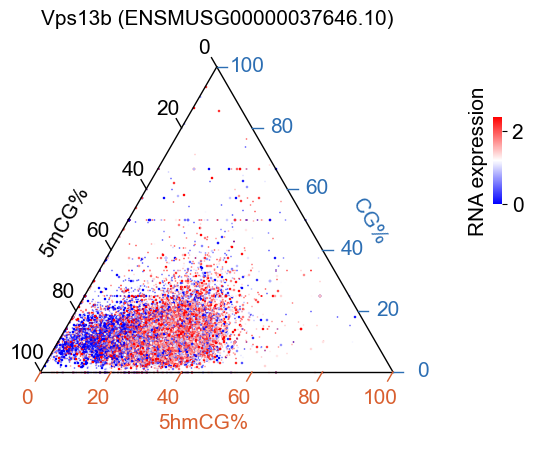

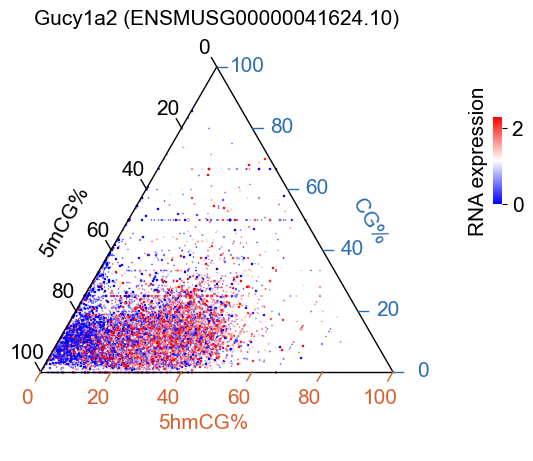

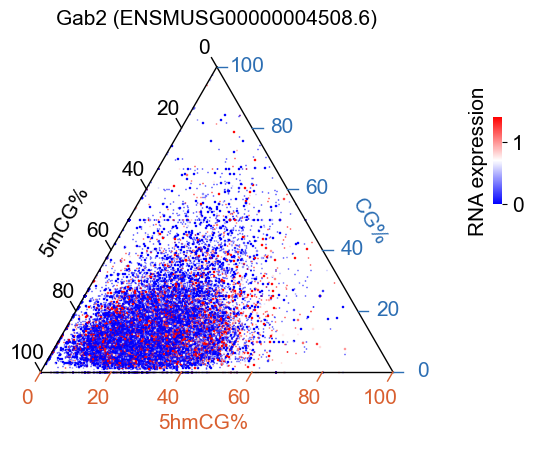

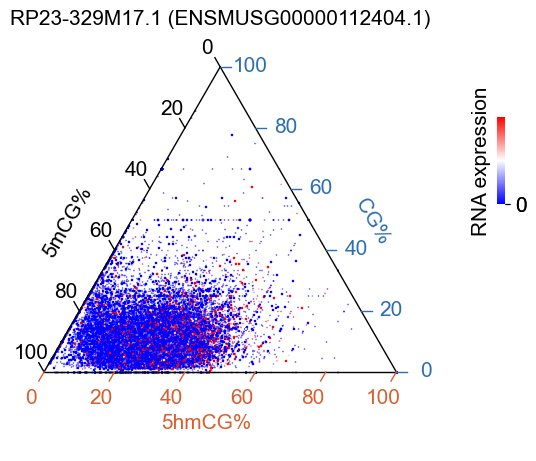

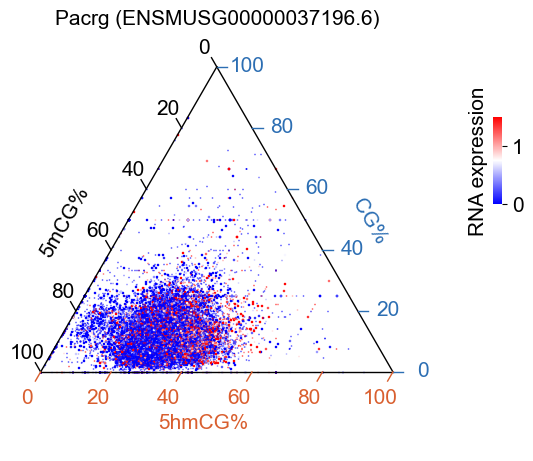

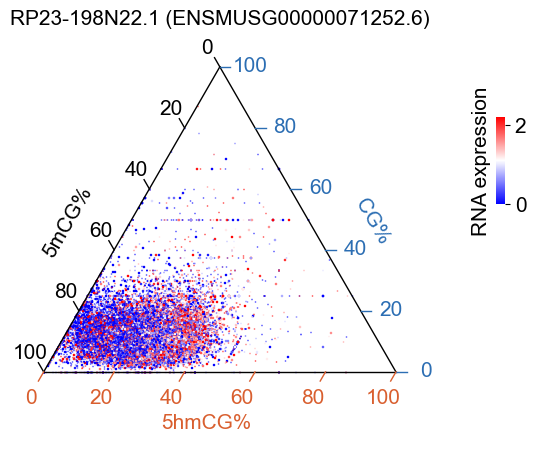

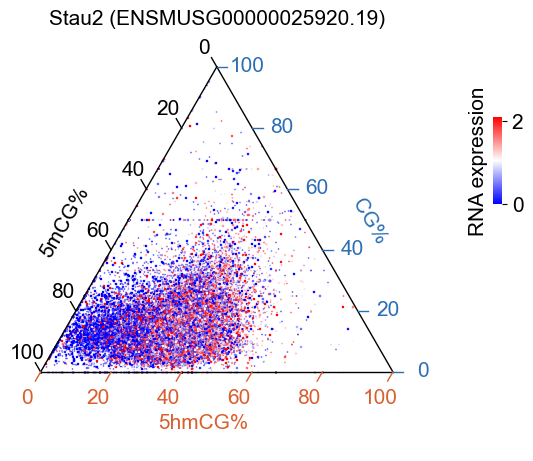

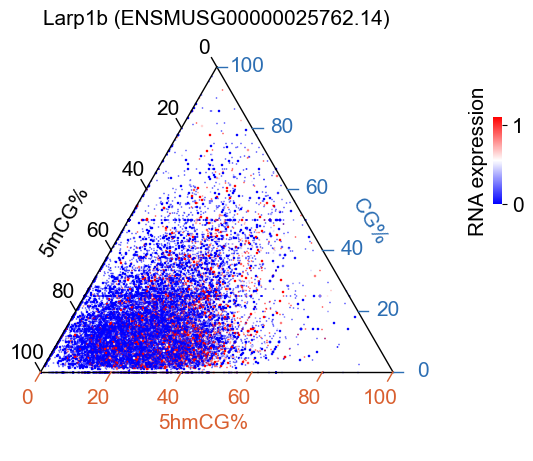

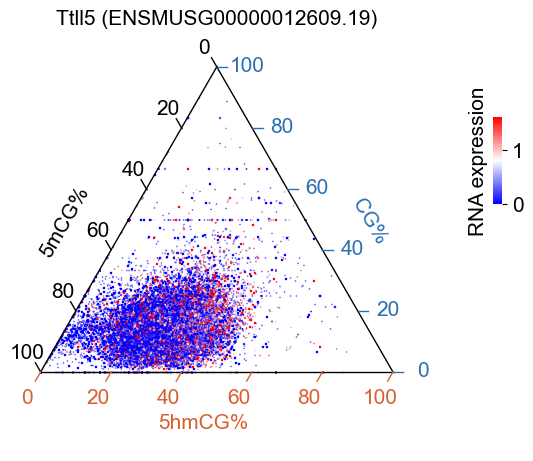

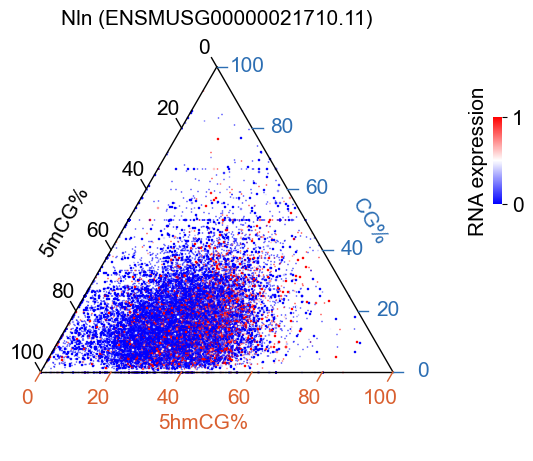

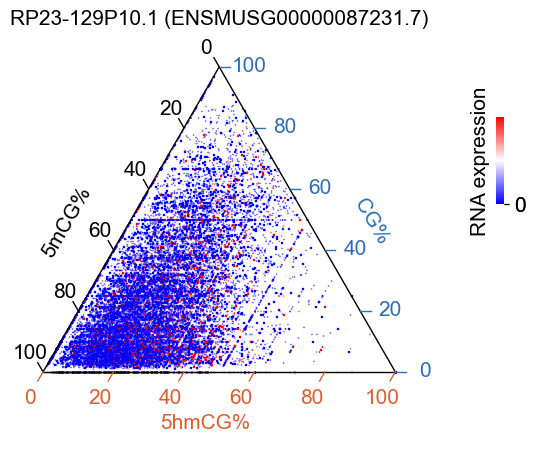

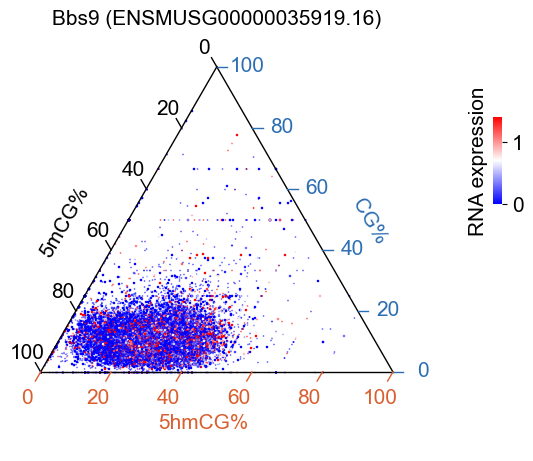

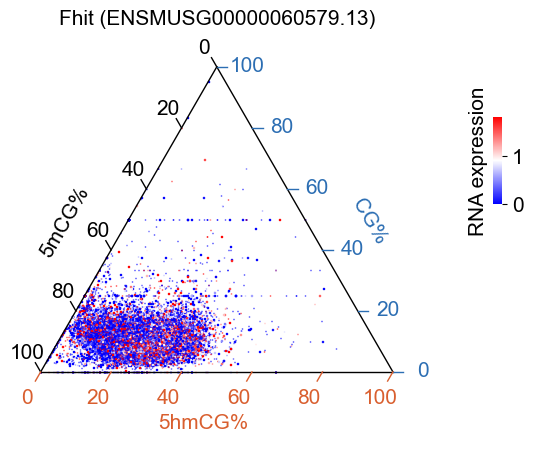

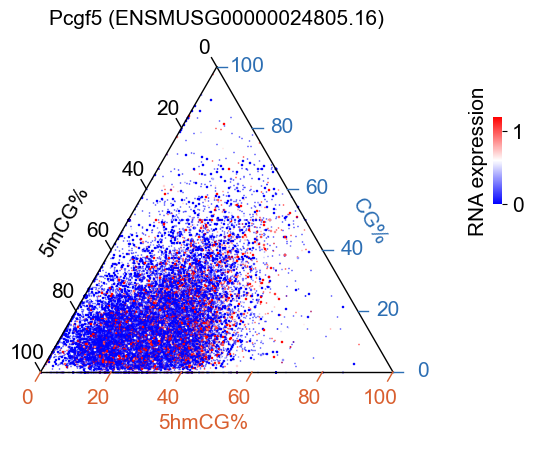

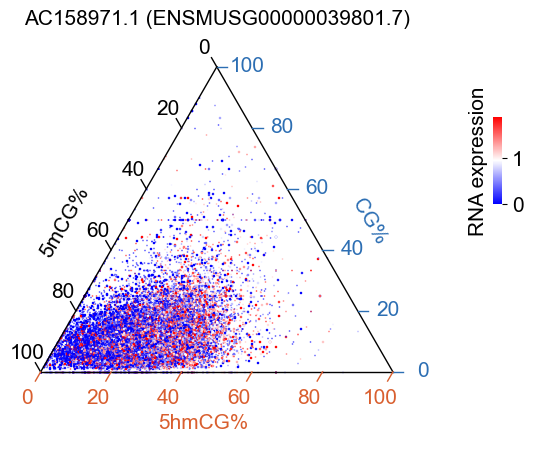

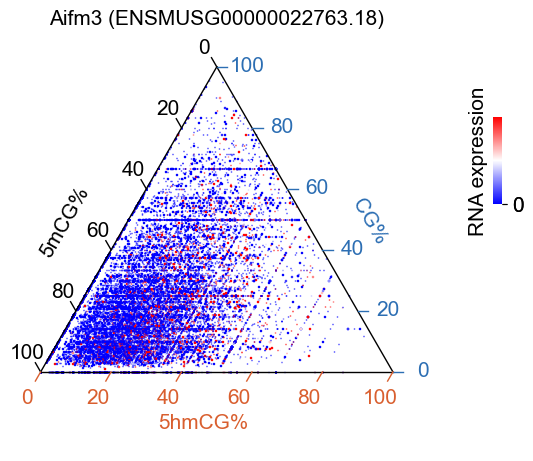

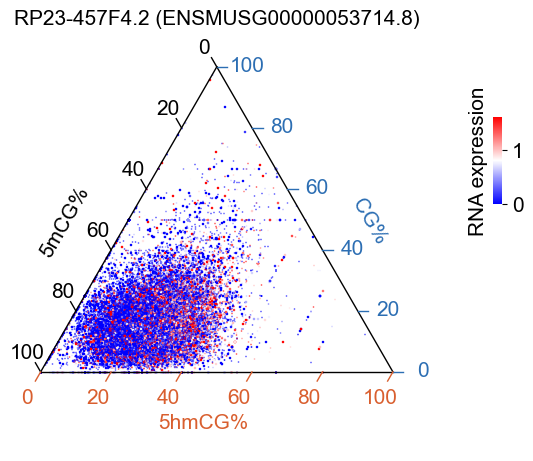

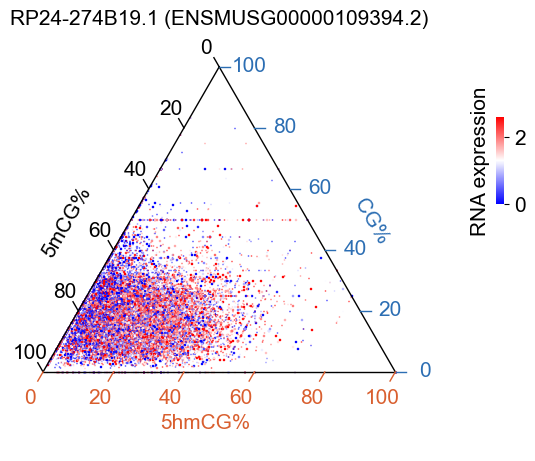

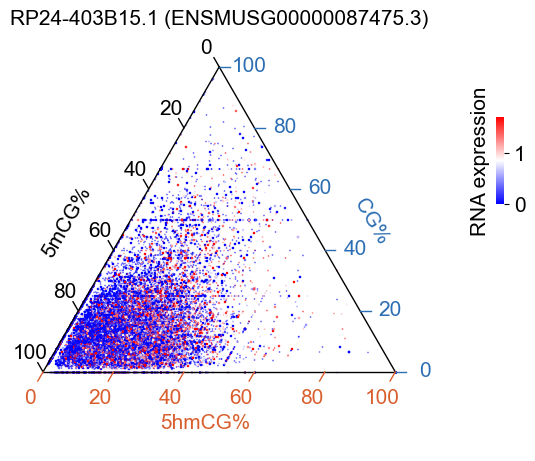

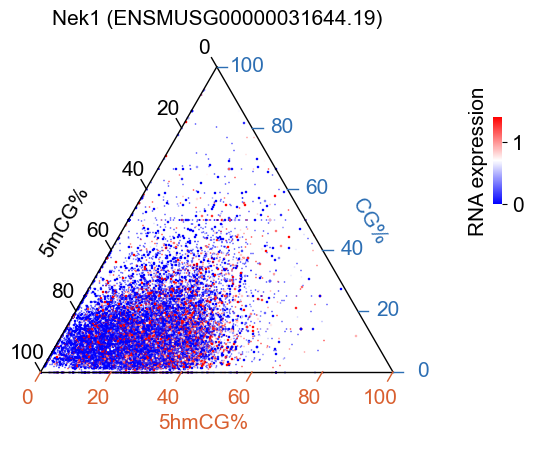

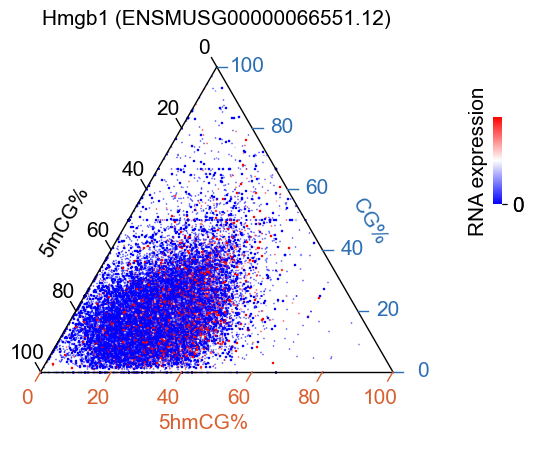

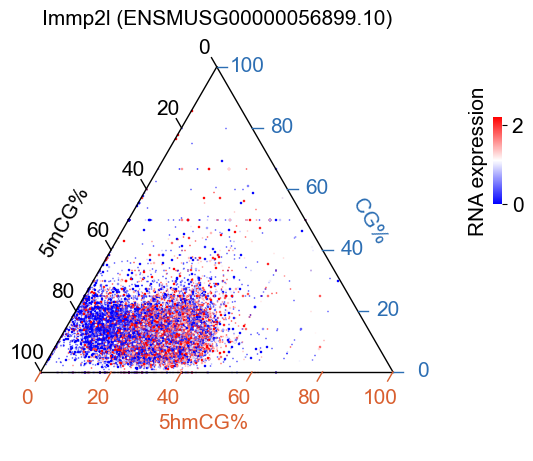

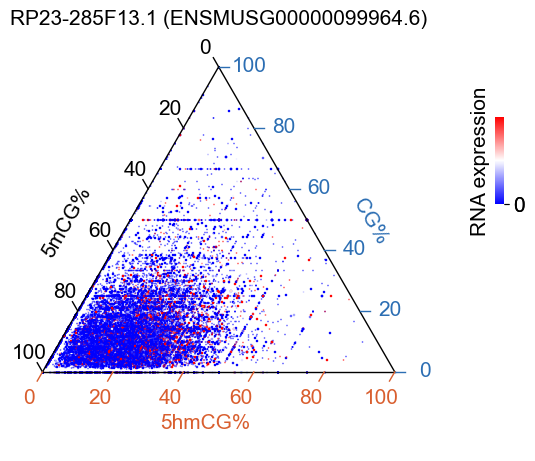

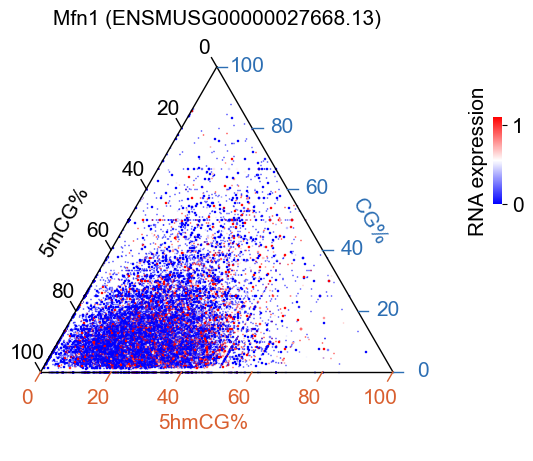

In [ ]:
for gene_ in tqdm(genes_df_yellow_sorted.iloc[:30,0]):
    gene_name=genes_df[genes_df["gene_id"]==gene_]["gene_name"].iloc[0]

    data_RNA=df_RNA.loc[meta_data2["RNA"], gene_]
    data_RNA.index=meta_data2["Unique_ID_match"]

    data_total5mC=df_total5mC.loc["allc_"+meta_data2["mC"], gene_]
    data_total5mC.index=meta_data2["Unique_ID_match"]

    data_5hmC=df_5hmC.loc["allc_"+meta_data2["hmC"], gene_]
    data_5hmC.index=meta_data2["Unique_ID_match"]

    data_5mC=data_total5mC-data_5hmC
    # note that data_5mC may contain negative values


    plt.rcParams["figure.autolayout"] = True
    temp_scale=3
    
    ## Boundary and Gridlines
    fig, (ax,cbar_ax) = plt.subplots(1,2,
                                     figsize=(temp_scale*46/25.4, temp_scale*40/25.4),
                                    width_ratios=[40,6])
    ax.set_aspect('equal')
    
    scale = 100
    figure, tax = ternary.figure(scale=scale,ax=ax)
    #figure.set_size_inches(temp_scale*60/25.4, temp_scale*60/25.4)
    tax.set_background_color("white")
    # Draw Boundary and Gridlines
    tax.boundary(linewidth=1)
    #tax.gridlines(color="black", multiple=6)
    #tax.gridlines(color="blue", multiple=2, linewidth=0.5)

    data_of_points=pd.concat([data_5hmC, 1-data_total5mC, data_5mC, data_RNA],axis=1)
    # bottom, right, left is the default order
    # remove negative true 5mC points
    data_of_points=data_of_points[data_5mC>=0]
    
    points = data_of_points.iloc[:,:3].to_numpy()*100
    
    color_data = data_of_points.iloc[:,3]
    vmax_RNA=np.floor(np.quantile(data_RNA, 0.9)*10)/10
    
    # Scatter plot with colors
    tax.scatter(points, marker=',', c=color_data, cmap='bwr', s=0.1,
                vmin=0, vmax=vmax_RNA)

    # Set Axis labels and Title
    fontsize = temp_scale*5
    tax.set_title(f"{gene_name} ({gene_})\n", fontsize=fontsize)
    tax.left_axis_label("5mCG%", fontsize=fontsize, offset=0.18,color="black")
    tax.right_axis_label("CG%", fontsize=fontsize, offset=0.18,color="#2C6EB3")
    tax.bottom_axis_label("5hmCG%", fontsize=fontsize, offset=0.14,color="#D95F2F")
    
    # Set ticks
    tax.ticks(axis='lbr', linewidth=1, multiple=20, offset=0.03, fontsize=fontsize,
             clockwise=False, axes_colors={"l":"black", "b":"#D95F2F", "r":"#2C6EB3"})
    
    # set colorbar
    sm = plt.cm.ScalarMappable(cmap='bwr',
                norm=plt.Normalize(vmin=0, vmax=vmax_RNA))
    sm.set_array([])
    # Create an axis for the color bar to prevent overlap
    cbar=plt.colorbar(sm, ax=cbar_ax, shrink=1,aspect=10,
                 location="right", anchor=(0,0.7),ticks=[0,int(vmax_RNA)], format='%d')
    cbar.ax.tick_params(labelsize=fontsize)
    #cbar.ax.set_yticks((0, vmax_RNA))
    cbar.ax.set_ylabel("RNA expression", fontsize=fontsize)
    cbar.ax.yaxis.set_label_position('left')
    cbar_ax.axis("off")
    # Disable edges of the colorbar
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)
    
    # Remove default Matplotlib Axes
    tax.clear_matplotlib_ticks()
    tax.get_axes().axis('off')
    
    ternary.plt.savefig(f"{outdir}/plot_[5mCG -]_[5hmCG +]/{gene_name}.pdf")
    #ternary.plt.show()
    #break